<a href="https://colab.research.google.com/github/ashrafsohail42003/Training-project/blob/main/SyncVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clinical Data Science Pipeline: Sedation Risk & NLP Distress Analysis
This notebook implements a complete pipeline for analyzing patient clinical data, calculating distress scores via NLP, and predicting sedation requirements using XGBoost.

In [ ]:
!pip install -q transformers datasets accelerate xgboost scikit-learn imbalanced-learn

import pandas as pd
import numpy as np
import re
import torch
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

np.random.seed(42)
torch.manual_seed(42)

DEVICE = 0 if torch.cuda.is_available() else -1
print(f"Setup Complete. Using Device: {'GPU' if DEVICE == 0 else 'CPU'}")

Setup Complete. Using Device: GPU


In [ ]:

def load_and_fusion(notes_path, meds_path, vitals_path):
    df_notes = pd.read_csv(notes_path)
    df_meds = pd.read_csv(meds_path)
    df_vitals = pd.read_csv(vitals_path)

    meds_agg = df_meds[df_meds['medication_name'].str.lower() == 'midazolam'].groupby('patient_id')['dosage_mg'].sum().reset_index()
    meds_agg.columns = ['patient_id', 'total_midazolam_mg']
    meds_agg['is_high_sedation'] = (meds_agg['total_midazolam_mg'] > 5).astype(int)

    df_vitals['bmi'] = df_vitals.apply(
        lambda x: round(x['weight_kg'] / ((x['height_cm']/100)**2), 2) if x['height_cm'] > 0 else 0,
        axis=1
    )
    merged_df = df_vitals.merge(df_notes, on='patient_id', how='inner')
    final_df = merged_df.merge(meds_agg, on='patient_id', how='left')

    final_df['total_midazolam_mg'] = final_df['total_midazolam_mg'].fillna(0)
    final_df['is_high_sedation'] = final_df['is_high_sedation'].fillna(0).astype(int)

    return final_df
PATHS = {
    'notes': '/content/drive/MyDrive/SyncVR/clinical_notes.csv',
    'meds': '/content/drive/MyDrive/SyncVR/medication_logs.csv',
    'vitals': '/content/drive/MyDrive/SyncVR/patients_vitals.csv'
}

final_df = load_and_fusion(PATHS['notes'], PATHS['meds'], PATHS['vitals'])

print(f"Data Fusion Complete. Shape: {final_df.shape}")
display(final_df[['patient_id', 'bmi', 'total_midazolam_mg', 'is_high_sedation']].head())


Data Fusion Complete. Shape: (1000, 10)


,patient_id,bmi,total_midazolam_mg,is_high_sedation
0,P0001,11.39,7.76,1
1,P0002,19.34,6.08,1
2,P0003,12.00,5.27,1
3,P0004,14.87,7.35,1
4,P0005,22.46,7.14,1


In [ ]:
import seaborn as sns
from IPython.display import display

def perform_comprehensive_eda(df):
    print("="*60)
    print("1 & 2. BASIC INFO & NUMERICAL DESCRIPTION")
    print("="*60)
    print("\n--- DataFrame Info ---")
    df.info()

    # 1. Split numerical and categorical columns
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

    print(f"\n-> Numerical Columns ({len(num_cols)}): {num_cols}")
    print(f"-> Categorical Columns ({len(cat_cols)}): {cat_cols}")

    # 2. Show description for numerical data
    if num_cols:
        print("\n--- Numerical Data Description ---")
        display(df[num_cols].describe())

    print("\n" + "="*60)
    print("3. CATEGORICAL DATA: UNIQUE VALUES")
    print("="*60)
    if cat_cols:
        for col in cat_cols:
            unique_count = df[col].nunique()
            # Grabbing top 10 unique values to avoid massive terminal outputs
            unique_vals = df[col].dropna().unique()[:10]
            print(f"• '{col}': {unique_count} unique values. Sample: {unique_vals}")
    else:
        print("No categorical columns found.")

    print("\n" + "="*60)
    print("6 & 7. MISSING VALUES AND DUPLICATES")
    print("="*60)

    # 6. Print missing values
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0]
    if not missing_data.empty:
        print("\n--- Missing Values (Count) ---")
        print(missing_data.sort_values(ascending=False))
    else:
        print("\n--- Missing Values ---\nNo missing values found!")

    # 7. Show duplicated rows
    duplicates = df.duplicated().sum()
    print(f"\n--- Duplicated Rows ---\nTotal duplicates: {duplicates}")

    print("\n" + "="*60)
    print("4 & 5. VISUALIZATIONS: BOXPLOTS FOR OUTLIER DETECTION")
    print("="*60)

    # 4 & 5. Show boxplots for numerical data to identify outliers
    if num_cols:
        # Calculate dynamic grid size based on number of numerical columns
        num_plots = len(num_cols)
        cols_grid = 3
        rows_grid = int(np.ceil(num_plots / cols_grid))

        fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(15, 5 * rows_grid))
        axes = axes.flatten() # Flatten to easily iterate

        for i, col in enumerate(num_cols):
            sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
            axes[i].set_title(f'Outlier Check: {col}', fontsize=10)
            axes[i].set_xlabel('')

        # Hide any unused subplots if the grid is larger than the number of columns
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()
    else:
        print("No numerical columns available to plot.")


1 & 2. BASIC INFO & NUMERICAL DESCRIPTION

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          1000 non-null   object 
 1   age                 1000 non-null   int64  
 2   weight_kg           1000 non-null   float64
 3   height_cm           1000 non-null   int64  
 4   pre_op_hr           1000 non-null   int64  
 5   pre_op_bp_sys       1000 non-null   int64  
 6   bmi                 1000 non-null   float64
 7   note_text           1000 non-null   object 
 8   total_midazolam_mg  1000 non-null   float64
 9   is_high_sedation    1000 non-null   int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 78.3+ KB

-> Numerical Columns (8): ['age', 'weight_kg', 'height_cm', 'pre_op_hr', 'pre_op_bp_sys', 'bmi', 'total_midazolam_mg', 'is_high_sedation']
-> Categorical Columns (2): ['patient

,age,weight_kg,height_cm,pre_op_hr,pre_op_bp_sys,bmi,total_midazolam_mg,is_high_sedation
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,40.236000,57.994200,156.371000,77.753000,123.076000,25.037750,3.486770,0.15000
std,20.484529,22.857829,20.011692,10.566155,12.611712,12.396057,1.658114,0.35725
min,5.000000,20.100000,120.000000,53.000000,90.000000,6.220000,1.000000,0.00000
25%,22.000000,38.675000,139.000000,71.000000,114.000000,15.342500,2.160000,0.00000
50%,40.500000,56.450000,158.000000,76.000000,122.000000,22.815000,3.285000,0.00000
75%,58.000000,77.500000,174.000000,83.000000,131.000000,32.192500,4.490000,0.00000
max,75.000000,100.000000,190.000000,118.000000,186.000000,66.740000,7.950000,1.00000



3. CATEGORICAL DATA: UNIQUE VALUES
• 'patient_id': 1000 unique values. Sample: ['P0001' 'P0002' 'P0003' 'P0004' 'P0005' 'P0006' 'P0007' 'P0008' 'P0009'
 'P0010']
• 'note_text': 16 unique values. Sample: ['Routine intake complete. Patient vitals stable.'
 'History of post-op nausea and extreme anxiety regarding needles.'
 'Significant distress noted during intake. Patient is visibly shaking and tearful.'
 'Patient extremely combative and anxious about the procedure.'
 'Consent obtained. Patient ready for transfer to pre-op.'
 'Mother reports child has severe anxiety during previous IV starts.'
 'Patient present for outpatient procedure. Medical history reviewed.'
 'Patient appears highly anxious; history of needle phobia; requested extra sedation last time.'
 'Intake complete; patient appears relaxed and shows no anxiety.'
 'No signs of distress. Patient is calm and cooperative.']

6 & 7. MISSING VALUES AND DUPLICATES

--- Missing Values ---
No missing values found!

--- Duplicated Row

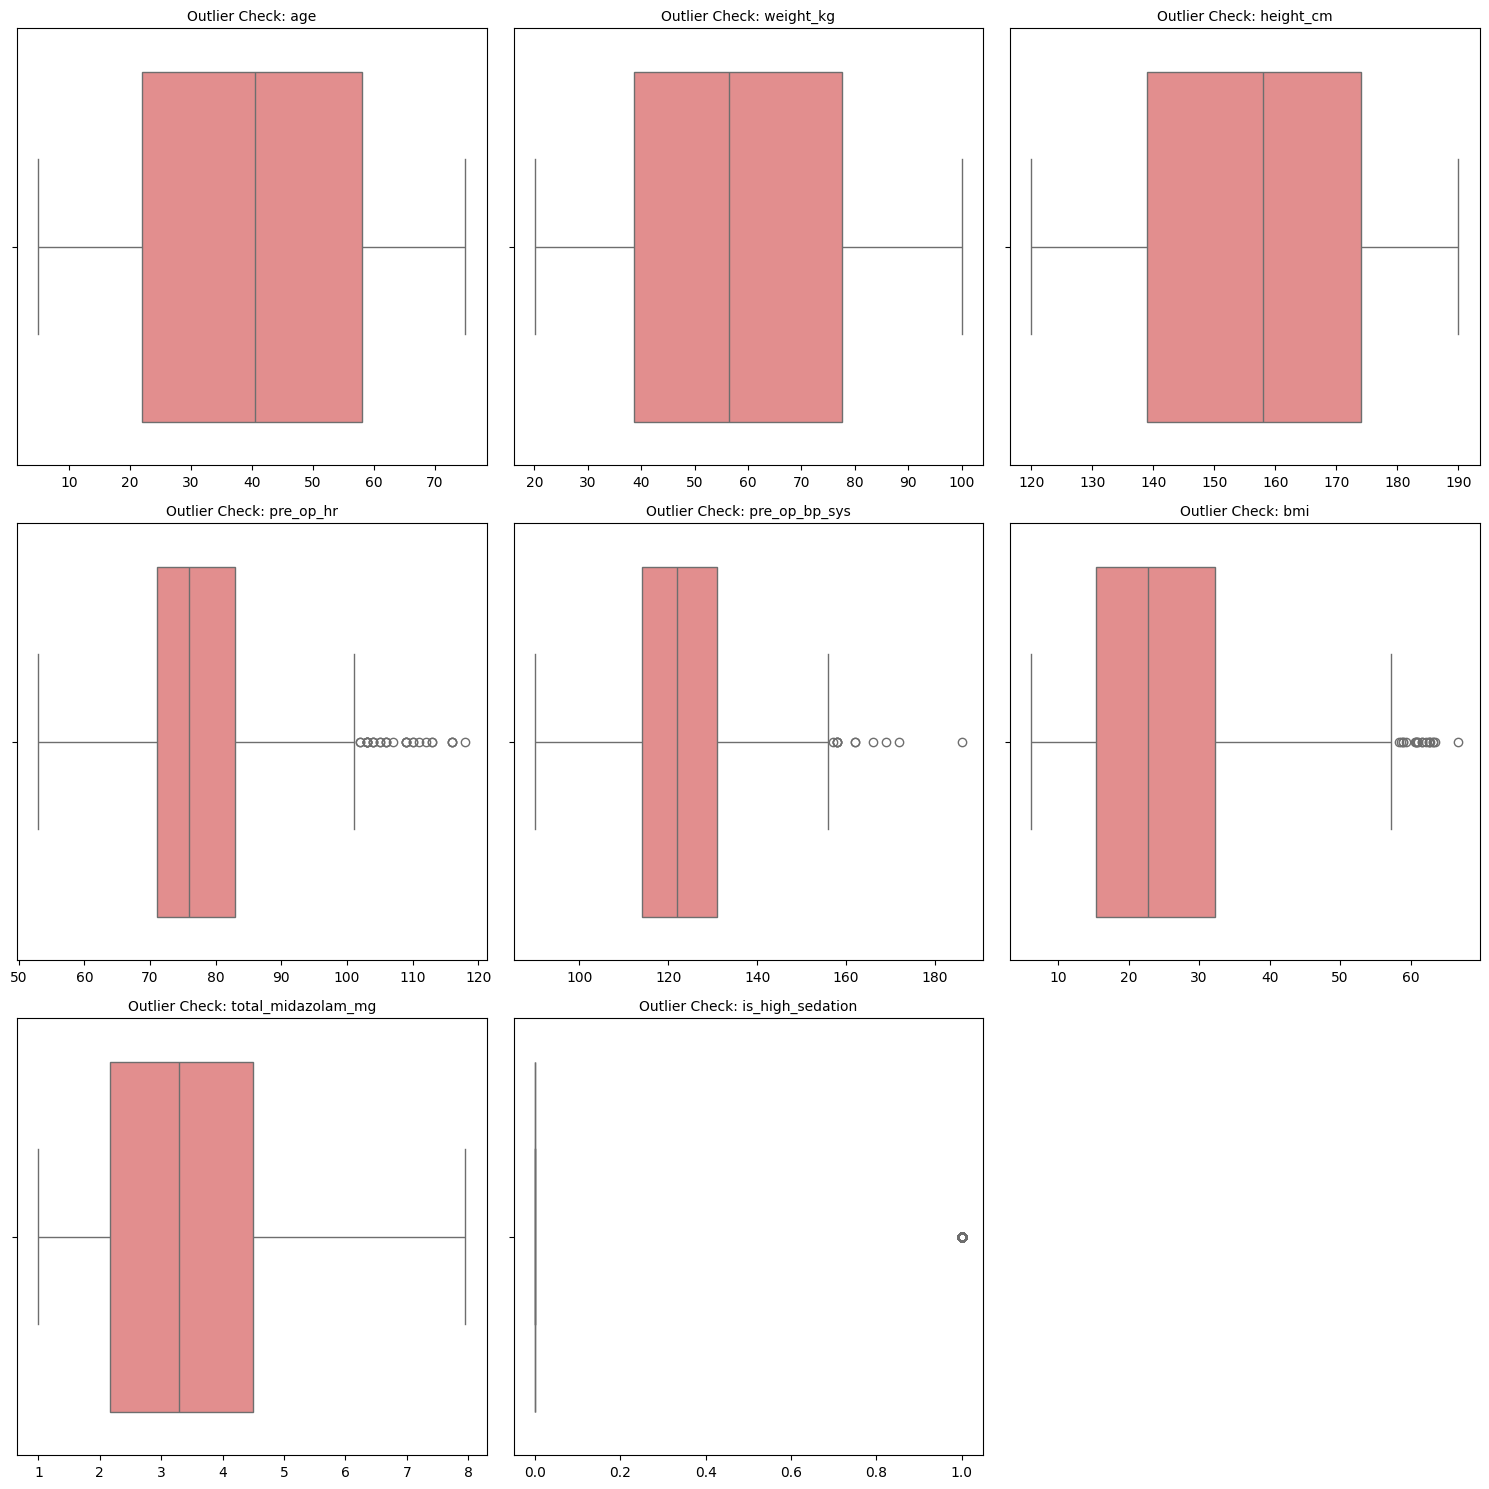

In [ ]:
perform_comprehensive_eda(final_df)

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          1000 non-null   object 
 1   age                 1000 non-null   int64  
 2   weight_kg           1000 non-null   float64
 3   height_cm           1000 non-null   int64  
 4   pre_op_hr           1000 non-null   int64  
 5   pre_op_bp_sys       1000 non-null   int64  
 6   bmi                 1000 non-null   float64
 7   note_text           1000 non-null   object 
 8   total_midazolam_mg  1000 non-null   float64
 9   is_high_sedation    1000 non-null   int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 78.3+ KB


In [ ]:
# ==========================================
# 3. Task B: Natural Language Processing (NLP) - Distress Scoring
# ==========================================

def calculate_nlp_distress(df):
    print("Initializing Transformer Pipeline...")
    classifier = pipeline(
        "sentiment-analysis",
        model="distilbert-base-uncased-finetuned-sst-2-english",
        device=DEVICE
    )

    KEYWORDS = {
        'anxiety': 0.8, 'anxious': 0.8, 'distress': 0.8,
        'shaking': 0.7, 'tearful': 0.7, 'combative': 0.95,
        'phobia': 0.85, 'panic': 1.0, 'agitated': 0.85
    }

    NEGATION_RE = re.compile(r"\b(no|not|denies|without|none|negative|shows no|denied)\b", re.I)

    unique_notes = df['note_text'].unique().tolist()
    print(f"Processing {len(unique_notes)} unique clinical notes...")

    results = classifier(unique_notes, truncation=True, batch_size=32)

    note_score_map = {}
    for note, res in zip(unique_notes, results):
        note_lower = note.lower()

        t_score = res['score'] if res['label'] == 'NEGATIVE' else (1 - res['score'])

        relevant_weights = [weight for kw, weight in KEYWORDS.items() if kw in note_lower]
        k_score = np.mean(relevant_weights) if relevant_weights else 0.1

        if NEGATION_RE.search(note_lower):
            final_score = 0.05
        else:
            final_score = (0.6 * t_score) + (0.4 * k_score)

        note_score_map[note] = round(float(np.clip(final_score, 0, 1)), 4)

    df['distress_score'] = df['note_text'].map(note_score_map)
    return df

final_df = calculate_nlp_distress(final_df)

print("\nNLP Scoring Complete.")
display(final_df[['note_text', 'distress_score']].drop_duplicates().sort_values('distress_score', ascending=False).head(10))

Initializing Transformer Pipeline...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Processing 16 unique clinical notes...

NLP Scoring Complete.


,note_text,distress_score
3,Patient extremely combative and anxious about ...,0.9409
23,Patient appears highly anxious; history of nee...,0.9276
1,History of post-op nausea and extreme anxiety ...,0.9171
7,Mother reports child has severe anxiety during...,0.9073
2,Significant distress noted during intake. Pati...,0.8805
6,Consent obtained. Patient ready for transfer t...,0.4519
174,Requested non-pharmacological distraction meth...,0.3374
8,Patient present for outpatient procedure. Medi...,0.1011
163,Patient uses VR at home for gaming; very inter...,0.0668
165,Patient denies needle phobia. Calm demeanor.,0.0500


The number from 0 to 1 say the dengress of statment

Patient extremely combative and anxious about ... is more dengerss

but Patient denies needle phobia. Calm demeanor. is week

in NLP the st is convert to vector and mutiply in eq.



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE



def train_sedation_predictor(df):
    features = ['age', 'bmi', 'pre_op_hr', 'pre_op_bp_sys', 'distress_score']
    X = df[features]
    y = df['is_high_sedation']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y

    )
    print(f"Original class distribution: {np.bincount(y_train)}")
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    print(f"Resampled class distribution: {np.bincount(y_resampled)}")
    model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'

    )

    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred))



    auc_roc = roc_auc_score(y_test, y_prob)

    f1 = f1_score(y_test, y_pred)



    print(f"AUC-ROC Score: {auc_roc:.4f}")

    print(f"F1-Score: {f1:.4f}")



    return model, features



model, model_features = train_sedation_predictor(final_df)





Original class distribution: [680 120]
Resampled class distribution: [680 680]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       170
           1       0.96      0.90      0.93        30

    accuracy                           0.98       200
   macro avg       0.97      0.95      0.96       200
weighted avg       0.98      0.98      0.98       200

AUC-ROC Score: 0.9853
F1-Score: 0.9310


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:30:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


note that the
per is more than 95%
but i want the F1 because the data is unbalnce >> recall in 0 99 >> not good or bad
but in 1 F1 93% and recall is 90% is v.good

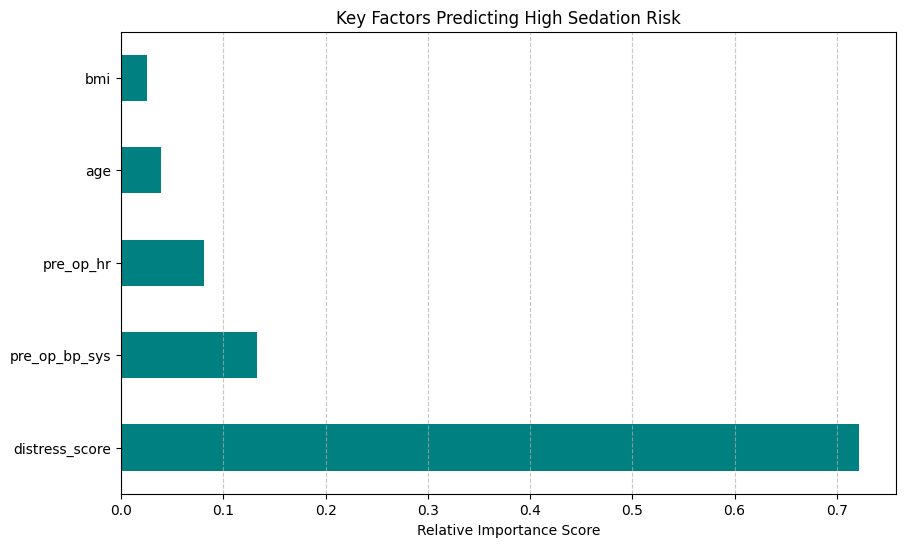


--- Normalized Scaled Comparison (First 5 Rows) ---


,patient_id,bmi_normalized,distress_score
0,P0001,0.085426,0.0406
1,P0002,0.216788,0.9171
2,P0003,0.095506,0.8805
3,P0004,0.142928,0.9409
4,P0005,0.268341,0.8805



--- Clinical Insight ---
Both BMI and Distress Score are now mapped to a 0-1 scale.
The model shows that the Distress Score (NLP) is the most dominant predictor for sedation needs.


In [ ]:
final_df['bmi_normalized'] = (final_df['bmi'] - final_df['bmi'].min()) / (final_df['bmi'].max() - final_df['bmi'].min())
scaled_features = ['age', 'bmi_normalized', 'pre_op_hr', 'pre_op_bp_sys', 'distress_score']
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(model.feature_importances_, index=model_features)
feat_importances.nlargest(5).plot(kind='barh', color='teal')
plt.title('Key Factors Predicting High Sedation Risk')
plt.xlabel('Relative Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



print("\n--- Normalized Scaled Comparison (First 5 Rows) ---")

display(final_df[['patient_id', 'bmi_normalized', 'distress_score']].head())



print("\n--- Clinical Insight ---")

print("Both BMI and Distress Score are now mapped to a 0-1 scale.")

print("The model shows that the Distress Score (NLP) is the most dominant predictor for sedation needs.")

from this graph
the relative importance score is important for distrss_score
now if i want to rewrite the model and code i use distrss_score (focus on )


#This patient shows a low predicted sedation requirement based on structured vitals and NLP-derived distress signals, where both BMI and physiological indicators fall within stable ranges and the distress score remains low. The model suggests that the primary driver of sedation need is psychological distress, which in this case is minimal, indicating no strong clinical justification for heavy sedation. Therefore, an XR-based intervention would provide a safer and more efficient approach by reducing unnecessary pharmacological exposure while maintaining adequate procedural tolerance.